# 用 networkx 求最小生成树及应用

T = nx.minimum_spanning_tree(G, weight='weight', algorithm='kruskal')

常用参数

G (必选参数)  
类型：networkx.Graph  
含义：输入的图，必须是一个无向图。它可以是带权图，也可以是无权图。如果是无权图，weight 参数会被忽略。

weight (可选参数)  
类型：str 或 None  
默认值：'weight'  
含义：指定边的权重属性名。图中的边需要有权重，且该权重可以通过 weight 属性来指定。如果没有权重，None 可以作为参数。如果使用默认 'weight'，则假定图中的每条边都有一个 weight 属性。  

algorithm (可选参数)  
类型：str  
默认值：'kruskal'  
含义：指定用于计算最小生成树的算法。可以选择以下两种算法：  
'kruskal'：使用 Kruskal 算法（边的排序+并查集）。适用于边数较少的图。  
'prim'：使用 Prim 算法（从一个节点出发，不断扩展）。适用于边数较多的图。  

返回值  
返回类型：networkx.Graph  
返回含义：返回一个新的图对象，该图包含输入图 G 中的所有顶点，并且是 G 的最小生成树。该图的边是最小生成树中的边，边的权重和输入图中的权重相同（如果图有权重的话）。


最小生成树为:
{(1, 5): 2, (2, 3): 4, (3, 5): 1, (3, 4): 2}
最小生成树的长度为:
9


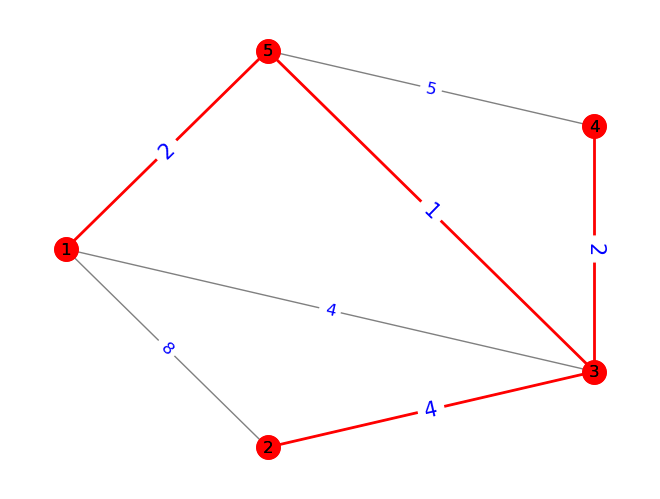

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 定义图的边和权重
L = [(1, 2, 8), (1, 3, 4), (1, 5, 2), (2, 3, 4), (3, 4, 2), (3, 5, 1), (4, 5, 5)]
G = nx.Graph()
G.add_nodes_from(range(1, 6))
G.add_weighted_edges_from(L)

# 计算最小生成树
T = nx.minimum_spanning_tree(G)  # 返回的是图，与 G 类型相同，也可用于画图

# 提取最小生成树的边权重
w = nx.get_edge_attributes(T, 'weight')  # 返回字典{(u, v): weight}边及其权值

# 获取原图的边权重
edge_labels = nx.get_edge_attributes(G, 'weight')

TL = sum(w.values())  # 计算最小生成树的长度

print(f"最小生成树为:\n{w}")
print(f"最小生成树的长度为:\n{TL}")

# 布局设置
pos = nx.shell_layout(G)

# 绘制原图（灰色边）
nx.draw(G, pos, node_size=280, with_labels=True, node_color='r', edge_color='gray')

# 绘制原图的边权重标签
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, font_color='blue')

# 绘制最小生成树（红色边）
nx.draw(T, pos, node_size=280, with_labels=True, node_color='r', edge_color='red', width=2)

# 绘制最小生成树的边权重标签
nx.draw_networkx_edge_labels(T, pos, edge_labels=w, font_size=15, font_color='b')

# 显示图
plt.show()


最小生成树为:
{(1, 5): 2, (2, 3): 4, (3, 5): 1, (3, 4): 2}
最小生成树的长度为:
9


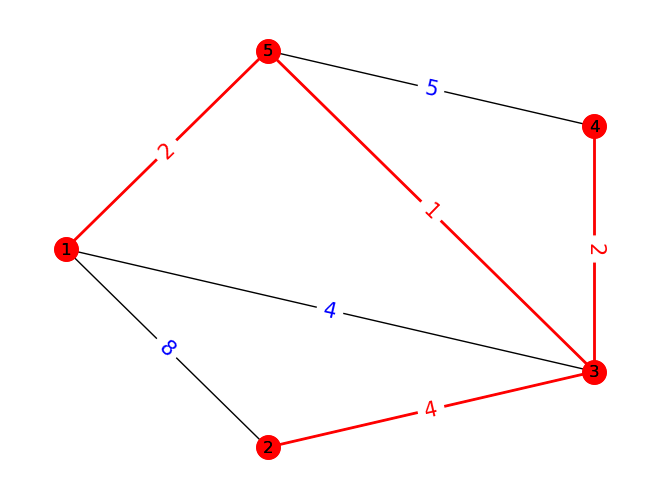

In [23]:
# Prim算法
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

L = [(1, 2, 8), (1, 3, 4), (1, 5, 2), (2, 3, 4), (3, 4, 2), (3, 5, 1), (4, 5, 5)]
G = nx.Graph()
G.add_nodes_from(range(1, 6))
G.add_weighted_edges_from(L)

T = nx.minimum_spanning_tree(G, algorithm='prim')
w = nx.get_edge_attributes(T, 'weight')
edge_labels = nx.get_edge_attributes(G, 'weight')
TL = sum(w.values())

print(f"最小生成树为:\n{w}")
print(f"最小生成树的长度为:\n{TL}")

pos = nx.shell_layout(G)
# 原图
nx.draw(G, pos, node_size=280, with_labels=True, node_color='r')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=15, font_color='blue')
# 最小生成树
nx.draw(T, pos, node_size=280, with_labels=True, node_color='r', edge_color='red', width=2)
nx.draw_networkx_edge_labels(T, pos, edge_labels=w, font_size=15, font_color='r')
plt.show()

10.14
已知 8 口油井，相互之间的距离如表 10.4 所列。已知 1 号油井离海岸最近，为 5n mile（1n mile = 1.852km）。问从海岸经 1 号油井铺设油管将各油井连接起来，应如何铺设使油管长度最短。

#### 表 10.4 各油井间距离 （单位：n mile）
|    | 2    | 3    | 4    | 5    | 6    | 7    | 8    |
|----|------|------|------|------|------|------|------|
| 1  | 1.3  | 2.1  | 0.9  | 0.7  | 1.8  | 2.0  | 1.5  |
| 2  |      | 0.9  | 1.8  | 1.2  | 2.6  | 2.3  | 1.1  |
| 3  |      |      | 2.6  | 1.7  | 2.5  | 1.9  | 1.0  |
| 4  |      |      |      | 0.7  | 1.6  | 1.5  | 0.9  |
| 5  |      |      |      |      | 0.9  | 1.1  | 0.8  |
| 6  |      |      |      |      |      | 0.6  | 1.0  |
| 7  |      |      |      |      |      |      | 0.5  |

邻接矩阵:
[[0.  0.  0.  0.  0.7 0.  0.  0. ]
 [0.  0.  0.9 0.  0.  0.  0.  0. ]
 [0.  0.9 0.  0.  0.  0.  0.  1. ]
 [0.  0.  0.  0.  0.7 0.  0.  0. ]
 [0.7 0.  0.  0.7 0.  0.  0.  0.8]
 [0.  0.  0.  0.  0.  0.  0.6 0. ]
 [0.  0.  0.  0.  0.  0.6 0.  0.5]
 [0.  0.  1.  0.  0.8 0.  0.5 0. ]]
油管的长度为: 10.2(n mile)


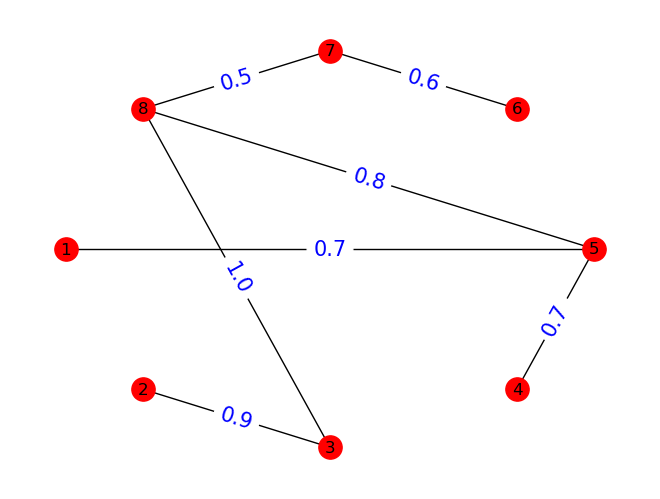

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

a = pd.read_excel("Pdata10_14.xlsx", header=None)  # 表格没有列名，header=None，防止将第1行当作列名
b = a.values  # 将 DataFrame(数据框) 转换为 array(数组)，原NaN值变成nan
b[np.isnan(b)] = 0  # 让空值nan变为0, 7x7

c = np.zeros((8, 8))  # 邻接矩阵初始化
c[0:7, 1:8] = b  # b填充c的上三角构造邻接矩阵

G = nx.Graph(c)  # 根据邻接矩阵创建无向图

T = nx.minimum_spanning_tree(G)
# w = nx.get_edge_attributes(T)  # 提取字典数据
# TL = sum(w.values())  # 计算最小生成树的长度
d = nx.to_numpy_array(T)  # 返回最小生成树的邻接矩阵(实际为array)
print(f"邻接矩阵:\n{d}")

W = d.sum() / 2 + 5  # 图为对称矩阵，故 /2，1号点距海岸5 n mile，故 +5
print(f"油管的长度为: {W}(n mile)")

s = dict(zip(range(8), range(1, 9)))  # 构造用于顶点标注的标号字典


pos = nx.shell_layout(G)
w = nx.get_edge_attributes(T, 'weight')

plt.rcParams['font.size'] = 16
# 画最小生成树
nx.draw(T, pos, node_size=280, labels=s, node_color='r')
nx.draw_networkx_edge_labels(T, pos, edge_labels=w, font_size=15, font_color='blue')
plt.savefig("油管最小生成树.png", dpi=500)
plt.show()